In [5]:
import numpy as np
import pandas as pd


In [11]:
data  = pd.read_csv('data.csv')


In [3]:
data.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [12]:
data.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)


In [ ]:
class NaiveBayes:
    def fit(self, X, y):
        self.y = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.y)

        # Calculate mean, var, and prior for each class
        self.mean= {}
        self.var = {}
        self.priors = {}

        self.mean = [np.mean(X[y == c], axis = 0) for c in self.y]
        self.var = [np.var(X[y == c], axis = 0) for c in self.y]
        self.priors = [len(y[y == c]) / n_samples for c in self.y]

    # Finding the likelihood of Gaussian distribution

    def likelihood(self, x):
        n_classes = np.unique(self.y)
        score = []
        for idx in enumerate(n_classes):
            mean = self.mean[idx[0]]
            var = self.var[idx[0]]
            log_prior = np.log(self.priors[idx[0]])
            posterior = log_prior + np.sum(np.log(self.pdf(x, idx[0]))) 
            score.append(posterior)
        return self.y[np.argmax(score)]

    # Gaussian probability density function

    def pdf(self,x ,idx):
        mean = self.mean[idx]
        var = self.var[idx]
        numerator = np.exp(- (x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator


            
    
    def predict(self, X):
        y_pred = [self.likelihood(x) for x in X]
        return np.array(y_pred)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [13]:
X = data.drop('diagnosis', axis=1).values
y = data['diagnosis'].values
y = [1 if i == 'M' else 0 for i in y]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)






In [26]:
NB = NaiveBayes()
NB.fit(X_train, y_train)
y_pred = NB.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.9649122807017544


In [22]:

n_classes = np.unique(y)

print(type(n_classes))


<class 'numpy.ndarray'>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components = None

    def fit(self, X_data):
        self.mean = np.mean(X_data, axis = 0)
        X_data = X_data - self.mean
        cov = np.cov(X_data.T)

        eigenvalues, eigenvectors = np.linalg.eig(cov)
        eigenvectors = eigenvectors.T

        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[idx]

        self.components = eigenvectors[:self.n_components]

    def transform(self, X_data):
        X_data = X_data - self.mean
        return np.dot(X_data, self.components.T)


In [19]:
pca = PCA(n_components=2)
pca.fit(X)
X_projected = pca.transform(X)

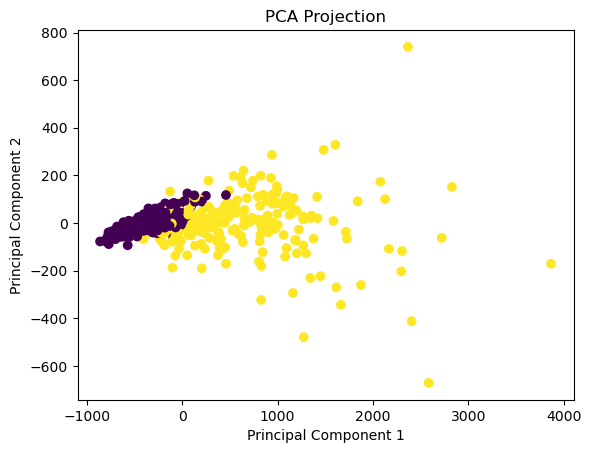

In [22]:
plt.scatter(X_projected[:, 0], X_projected[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')
plt.show()